In [148]:
import networkx as nx ## Network tools
import matplotlib.pyplot as plt
from collections import Counter
import numpy as np


In [149]:
data_sets = ["Datasets/net1.net", "Datasets/net2.net", "Datasets/net3.net", "Datasets/net4.net"]
positions_net5 = "Datasets/positions_net5.txt"

In [150]:
def create_pajek_graph(filename):
    multigraph = nx.read_pajek(filename)

    # Convert to simple network
    G = nx.Graph(multigraph)

    # Ensure that nodes are integers (Pajek sometimes read them as String)
    # G = nx.convert_node_labels_to_integers(G, label_attribute='original_label')
    return G

In [151]:
def top_n(dictionary, n=5):
    return sorted(dictionary.items(), key=lambda x: x[1], reverse=True)[:n]

def append_network_summary_line(graph_name, results: dict):
    """
    Appends a summary line to a TXT file with network descriptors.
    """
    num_nodes = results["num_nodes"]
    num_edges = results["num_edges"]
    min_degree = results["min_degree"]
    max_degree = results["max_degree"]
    avg_degree = results["avg_degree"]
    avg_clustering = results["avg_clustering"]
    assortativity = results["assortativity"]
    avg_path_length = results["avg_path_length"]
    diameter = results["diameter"]

    line = (
        f"Graph name: {graph_name} | "
        f"Nodes: {num_nodes} | "
        f"Edges: {num_edges} | "
        f"Min degree: {min_degree} | "
        f"Max degree: {max_degree} | "
        f"Avg degree: {avg_degree:.2f} | "
        f"Avg clustering: {avg_clustering:.4f} | "
        f"Assortativity: {assortativity:.4f} | "
        f"Avg path length: {avg_path_length:.2f} | "
        f"Diameter: {diameter}"
    )

    with open("Summary/data.txt", "a") as f:
        f.write(line + "\n")

def append_network_summary_Microscopic_analysis(file_name, G):
    degree_centrality = nx.degree_centrality(G)
    page_rank_centralities=nx.pagerank(G)
    eigenvector_centralities=nx.eigenvector_centrality(G)
    betweenness_centralities=nx.betweenness_centrality(G)
    closeness_centralities=nx.closeness_centrality(G)

    top_degree = top_n(degree_centrality)
    top_page_rank_centralities=top_n(page_rank_centralities)
    top_eigenvector_centralities=top_n(eigenvector_centralities)
    top_betweenness_centralities=top_n(betweenness_centralities)
    top_closeness_centralities=top_n(closeness_centralities)


    with open(file_name, "a") as f:
        f.write("Top 5 Degree Centrality:\n")
        for node, value in top_degree:
            f.write(f"Node {node}: {value:.4f}\n")
            
        f.write("\nTop 5 Betweenness Centrality:\n")
        for node, value in top_betweenness_centralities:
            f.write(f"Node {node}: {value:.4f}\n")

        f.write("\nTop 5 Eigenvector Centrality:\n")
        for node, value in top_eigenvector_centralities:
            f.write(f"Node {node}: {value:.4f}\n")

        f.write("\nTop 5 Closeness Centralities:\n")
        for node, value in top_closeness_centralities:
            f.write(f"Node {node}: {value:.4f}\n")

        f.write("\nTop 5 PageRank Centralities:\n")
        for node, value in top_page_rank_centralities:
            f.write(f"Node {node}: {value:.4f}\n")


In [152]:
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

def plot_degree_pdf_linear_and_loglog(results, file, weight=False, show=True, save_path=True):

    path = "Histograms/"+file+"_pdf_degree_linear_loglog.png"


    """
    Muestra la PDF (frecuencia relativa de grados o fuerza) en dos subplots:
    - Izquierda: escala lineal
    - Derecha: escala log-log

    Parámetros:
        results   : dict con al menos 'degrees'
        weight    : bool → para etiquetar eje como 'Strength' o 'Degree'
        show      : bool → mostrar el gráfico
        save_path : str → guardar imagen si se especifica ruta
    """
    # Usar los grados/fuerzas ya precalculados
    sequence = results["degrees"]
    if weight:
        xlabel = "Strength (s)"
    else:
        xlabel = "Degree (k)"

    # Calcular PDF normalizada
    degree_count = Counter(sequence)
    degrees, counts = zip(*sorted(degree_count.items()))
    pdf = np.array(counts) / sum(counts)

    # Crear subplots
    fig, axs = plt.subplots(1, 2, figsize=(12, 5))

    # Escala lineal
    axs[0].bar(degrees, pdf, width=0.8, color='skyblue', edgecolor='black')
    axs[0].set_title(f"PDF of {xlabel} (Linear Scale)", fontsize=14)
    axs[0].set_xlabel(xlabel, fontsize=12)
    axs[0].set_ylabel(f"P({xlabel})", fontsize=12)
    axs[0].grid(True, linestyle='--', alpha=0.6)

    # Escala log-log
    axs[1].bar(degrees, pdf, width=0.8, color='skyblue', edgecolor='black')
    axs[1].set_xscale('log')
    axs[1].set_yscale('log')
    axs[1].set_title(f"PDF of {xlabel} (Log-Log Scale)", fontsize=14)
    axs[1].set_xlabel(xlabel, fontsize=12)
    axs[1].set_ylabel(f"P({xlabel})", fontsize=12)
    axs[1].grid(True, which='both', linestyle='--', alpha=0.6)

    plt.tight_layout()

    # Guardar o mostrar
    if save_path:
        plt.savefig(path)
    if show:
        plt.show()
    else:
        plt.close()


def fit_CCDF(results, file,  weight=False):
    """
    Calcula y grafica el CCDF y ajusta una ley de potencia usando los datos precomputados.
    
    Parámetros:
        results : dict → debe contener:
            - 'degrees': lista de grados (o fuerza si ponderado)
            - 'num_nodes': número total de nodos
        weight : bool → para cambiar etiquetas (solo visual)
    """
    degree_sequence = results["degrees"]
    num_nodes = results["num_nodes"]

    # Conteo de grados
    degree_counts = Counter(degree_sequence)
    min_degree = min(degree_sequence)
    max_degree = max(degree_sequence)

    degrees = list(range(min_degree, max_degree + 1))
    degree_count = [degree_counts.get(k, 0) for k in degrees]

    # Filtrar ceros
    degrees = [d for i, d in enumerate(degrees) if degree_count[i] != 0]
    degree_count = [c for c in degree_count if c != 0]

    # Cálculo de CDF y CCDF
    cdf = np.cumsum(degree_count) / num_nodes
    ccdf = 1 - cdf

    # Ajuste log-log (descartando el último valor para evitar log(0))
    log_degree_fit = np.log(degrees[:-1])
    log_ccdf_fit = np.log(ccdf[:-1])

    m, b = np.polyfit(log_degree_fit, log_ccdf_fit, 1)
    theoretical = [np.exp(b) * k ** m for k in degrees]

    # Gráfico
    fig, ax = plt.subplots(1, 1, figsize=(5, 5))

    ax.plot(degrees, theoretical, color='black', label=r'$\gamma - 1 = %.2f$' % (-m))
    ax.scatter(degrees, ccdf, label='data')

    ax.set_xscale('log')
    ax.set_yscale('log')

    if not weight:
        ax.set_xlabel('$k$', fontsize=15)
        ax.set_ylabel('$CCDF(k)$', fontsize=15)
    else:
        ax.set_xlabel('$s$', fontsize=15)
        ax.set_ylabel('$CCDF(s)$', fontsize=15)

    ax.tick_params(which='major', axis='both', labelsize=13)
    ax.legend()

    plt.tight_layout()
    plt.savefig("Histograms/CCDF/"+file+".png")
    plt.close()
    # plt.show()

    return -m  # Devuelve gamma - 1 como indicador del ajuste


In [153]:
def numerical_description_of_network(G):
    '''
    Returns:
        Dictionary with:
        - Number of nodes
        - Number of edges
        - Min, max, avg degree
        - Average clustering
        - Assortativity
        - Average path length
        - Diameter
    '''
    import numpy as np
    import networkx as nx

    num_nodes = G.number_of_nodes()
    num_edges = G.number_of_edges()

    degrees = [deg for _, deg in G.degree()]
    min_deg = np.min(degrees)
    max_deg = np.max(degrees)
    avg_deg = np.mean(degrees)

    avg_clustering = nx.average_clustering(G)
    assortativity = nx.degree_assortativity_coefficient(G)

    if nx.is_connected(G):
        avg_path_length = nx.average_shortest_path_length(G)
        diameter = nx.diameter(G)
    else:
        largest_cc = max(nx.connected_components(G), key=len)
        G_sub = G.subgraph(largest_cc).copy()
        avg_path_length = nx.average_shortest_path_length(G_sub)
        diameter = nx.diameter(G_sub)

    return {
        "num_nodes": num_nodes,
        "num_edges": num_edges,
        "degrees": degrees,
        "min_degree": min_deg,
        "max_degree": max_deg,
        "avg_degree": avg_deg,
        "avg_clustering": avg_clustering,
        "assortativity": assortativity,
        "avg_path_length": avg_path_length,
        "diameter": diameter
    }




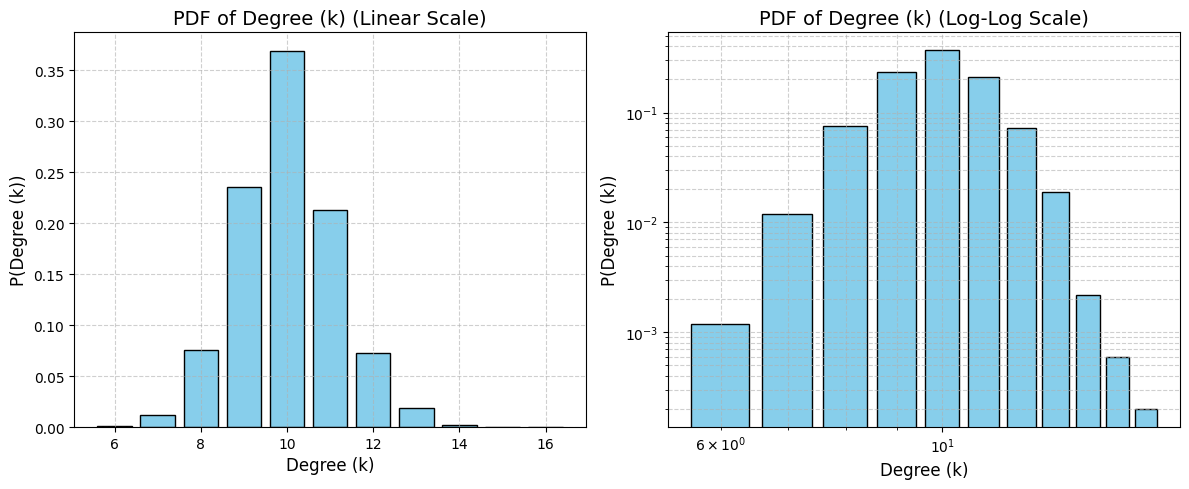

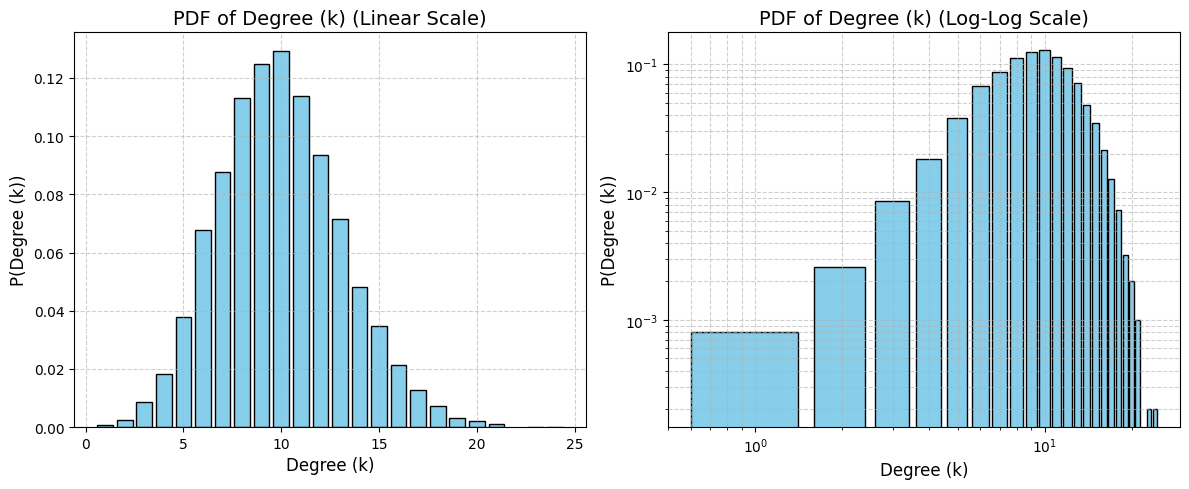

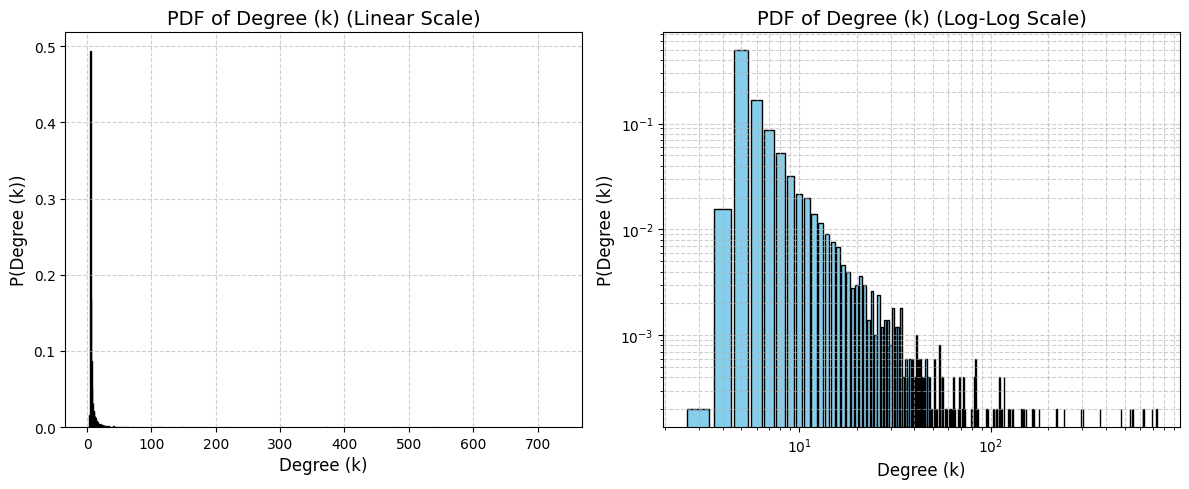

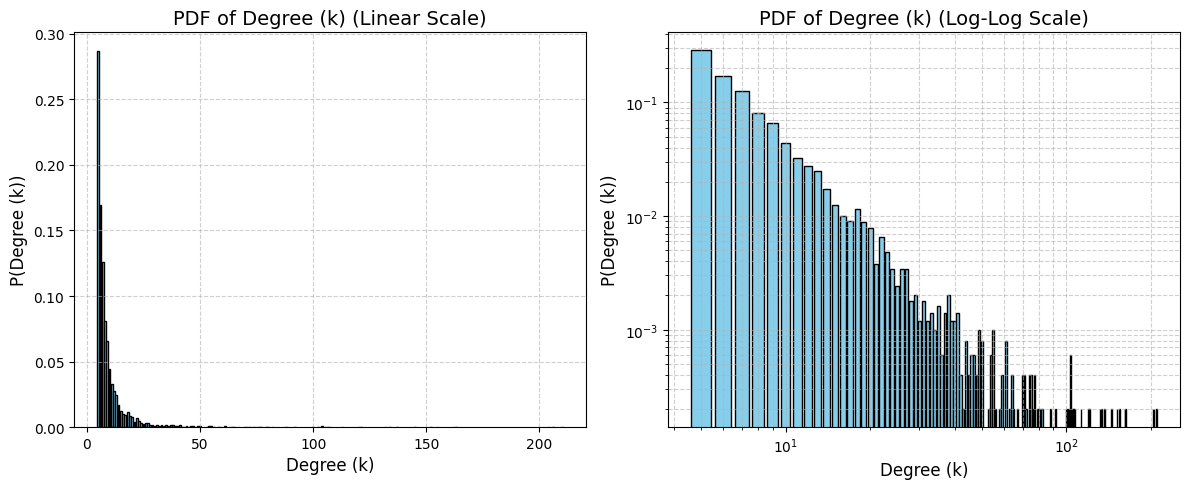

In [154]:

for file in data_sets:
    f_data = file.split('/')[1]
    f = file.split('/')[1].split('.')[0]


    file_histogram_name = "Histograms/"+f+".png"
    file_path = "Summary/"+f_data+".txt"

    summary_Microscopic_analysis = "Summary/"+f+".txt"


    # Load graph
    G = create_pajek_graph(file)

    # Get data from the network
    results = numerical_description_of_network(G)
    append_network_summary_line(file, results)
    append_network_summary_Microscopic_analysis(summary_Microscopic_analysis, G)

    fit_CCDF(results, f)
    plot_degree_pdf_linear_and_loglog(results, f, save_path=True)
